# Biomedical data analysis HO3

Yangxin Zhan Du (yangxin.zhan01@estudiant.upf.edu)

Last update: 7 February, 2026

# Data Cleaning and preparation

Importing the necessaries libraries

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, matthews_corrcoef, precision_score, recall_score,
    accuracy_score, make_scorer, RocCurveDisplay, auc
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from imblearn.metrics import specificity_score



Analyzing the training cohort provided in Supplementary Table 3 and the patient metadata in Supplementary Table 1 from the article 'Proteomic and Metabolomic Characterization of COVID-19 Patient Sera'.

In [46]:
df = pd.read_excel('./raw_data/table_s3.xlsx', sheet_name='Prot_and_meta_matrix', skiprows=1)

df_metadata = pd.read_excel('./raw_data/table_s1.xlsx', sheet_name= 'Clinical_information')

In [47]:
df_metadata = df_metadata[['Patient ID a','Group d','Sex g', 'Age (year)']]
df_metadata = df_metadata.rename(columns= {
    'Patient ID a': 'patient_id',
    'Group d' : 'group_disease',
    'Sex g' : 'sex',
    'Age (year)': 'age'
})

df_metadata['group_disease'] = df_metadata['group_disease'].map({
    0: 'healthy',
    1: 'non_covid_19',
    2: 'non_severe',
    3: 'severe'
})

df_metadata['sex'] = df_metadata['sex'].map({
    0: 'female',
    1: 'male'
})

In the dataset, there are records for proteins (791 entries) and metabolites (847 entries). As we are interested in protein we will get the protein subset.

In [48]:
df_protein = df.iloc[:791, :]

# Rename unnamed columns
df_protein = df_protein.rename(columns={
    'Unnamed: 0': 'Proteins', 
    'Unnamed: 1': 'Gene_symbol'
})

# Drop Gene_symbol column to facilitate the cleaning part
df_protein = df_protein.drop(columns=['Gene_symbol'])

# Transpose the dataframe
df_protein = df_protein.T

# Use first row as column names
df_protein.columns = df_protein.iloc[0]

# Remove the first row (now column names)
df_protein = df_protein.iloc[1:]

df_protein = df_protein.reset_index().rename(columns={'index': 'patient_id'})

df_protein

Proteins,patient_id,P04114,P01024,P02768,P01023,P02751,P0C0L5,P0C0L4,P02787,P00450,...,Q8TB36,Q76MJ5,Q6DHV5,Q8IUL8,Q9UBX5,Q9HCU9,O60333,Q8NHW5,Q3ZCW2,Q6IE36
0,XG1,1.535,1.243,0.904,0.742,1.687,0.923,1.28,0.945,1.08,...,NaN,NaN,1.507,0.913,0.778,0.754,NaN,1.758,NaN,NaN
1,XG2,1.444,1.067,1.03,0.897,1.457,0.828,0.874,0.901,1.018,...,NaN,NaN,1.018,1.081,0.799,1.071,NaN,1.286,NaN,NaN
2,XG3,1.245,1.166,0.94,0.799,0.805,2.302,1.867,0.838,1.219,...,NaN,NaN,1.031,0.837,0.983,0.97,NaN,1.388,NaN,NaN
3,XG27,0.819,1.056,0.933,0.928,0.649,1.101,0.997,0.867,1.016,...,NaN,NaN,0.981,1.362,1.133,0.934,NaN,1.392,NaN,NaN
4,XG26,1.136,1.079,0.925,0.746,0.618,1.422,1.52,0.76,1.1,...,NaN,NaN,0.848,1.151,0.709,1.042,NaN,1.254,NaN,NaN
5,XG4,1.502,1.068,1.047,0.963,0.923,1.131,1.156,0.87,0.697,...,NaN,NaN,1.024,NaN,0.87,NaN,NaN,0.718,NaN,0.801
6,XG5,1.163,0.943,1.057,0.774,1.287,0.932,0.751,0.821,0.846,...,NaN,NaN,0.886,NaN,0.818,NaN,NaN,0.01,NaN,1.368
7,XG6,0.514,0.728,0.954,1.001,0.864,0.546,0.738,1.211,0.882,...,NaN,NaN,0.56,NaN,1.387,NaN,NaN,0.522,NaN,1.521
8,XG29,0.779,0.957,0.917,1.101,0.913,1.215,2.153,1.031,1.106,...,NaN,NaN,0.95,NaN,0.828,NaN,NaN,0.647,NaN,1.209
9,XG31,1.737,1.202,0.886,0.975,0.716,1.263,1.513,0.909,1.15,...,NaN,NaN,1.089,NaN,0.78,NaN,NaN,8.542,NaN,0.349


In [49]:
df_metadata

,patient_id,group_disease,sex,age
0,XG1,non_severe,male,38
1,XG2,non_severe,male,36
2,XG3,non_severe,male,70
3,XG4,non_severe,male,33
4,XG5,non_severe,male,33
...,...,...,...,...
113,HC24,healthy,female,38
114,HC25,healthy,female,44
115,HC26,healthy,male,28
116,HC27,healthy,male,38


In [50]:
df_merged = pd.merge(df_metadata, df_protein, on='patient_id', how='inner')
df_merged

,patient_id,group_disease,sex,age,P04114,P01024,P02768,P01023,P02751,P0C0L5,...,Q8TB36,Q76MJ5,Q6DHV5,Q8IUL8,Q9UBX5,Q9HCU9,O60333,Q8NHW5,Q3ZCW2,Q6IE36
0,XG1,non_severe,male,38,1.535,1.243,0.904,0.742,1.687,0.923,...,NaN,NaN,1.507,0.913,0.778,0.754,NaN,1.758,NaN,NaN
1,XG2,non_severe,male,36,1.444,1.067,1.03,0.897,1.457,0.828,...,NaN,NaN,1.018,1.081,0.799,1.071,NaN,1.286,NaN,NaN
2,XG3,non_severe,male,70,1.245,1.166,0.94,0.799,0.805,2.302,...,NaN,NaN,1.031,0.837,0.983,0.97,NaN,1.388,NaN,NaN
3,XG4,non_severe,male,33,1.502,1.068,1.047,0.963,0.923,1.131,...,NaN,NaN,1.024,NaN,0.87,NaN,NaN,0.718,NaN,0.801
4,XG5,non_severe,male,33,1.163,0.943,1.057,0.774,1.287,0.932,...,NaN,NaN,0.886,NaN,0.818,NaN,NaN,0.01,NaN,1.368
5,XG6,non_severe,female,45,0.514,0.728,0.954,1.001,0.864,0.546,...,NaN,NaN,0.56,NaN,1.387,NaN,NaN,0.522,NaN,1.521
6,XG7,non_severe,female,46,1.206,1.016,0.995,0.781,1.502,1.091,...,0.647,NaN,1.611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,XG8,non_severe,male,21,1.255,1.014,1.117,0.908,1.21,1.078,...,0.254,NaN,1.179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,XG9,non_severe,male,63,1.066,0.824,1.041,1.235,0.898,1.114,...,0.784,NaN,1.341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,XG10,non_severe,male,27,1.062,1.056,1.049,1.085,0.693,1.318,...,NaN,0.765,0.629,NaN,NaN,1.234,NaN,0.391,NaN,NaN


Dropping columns by an NA threshold. To drop columns that have more than % missing values, for this case we selected a maximum of
20% missing values allowed.

In [51]:
treshold = int(df_merged.shape[0] * 0.80)
df_merged = df_merged.dropna(axis=1, thresh=treshold)

#we need to convert the protein columns (currently in object format) into numerical values to facilitate future data wrangling
cols_to_convert = [col for col in df_merged.columns if col not in ['patient_id', 'group_disease', 'sex', 'age']]
df_merged[cols_to_convert] = df_merged[cols_to_convert].apply(pd.to_numeric, errors='coerce')

df_merged

,patient_id,group_disease,sex,age,P04114,P01024,P02768,P01023,P02751,P0C0L5,...,Q5JXB2,Q9BXG8,P50851,Q9H3R1,Q9HCS7,P30531,P49221,Q92786,Q6DHV5,Q8NHW5
0,XG1,non_severe,male,38,1.535,1.243,0.904,0.742,1.687,0.923,...,0.819,0.547,1.439,1.287,1.074,0.553,0.982,0.904,1.507,1.758
1,XG2,non_severe,male,36,1.444,1.067,1.030,0.897,1.457,0.828,...,1.103,0.694,1.062,1.091,0.516,1.723,0.718,0.980,1.018,1.286
2,XG3,non_severe,male,70,1.245,1.166,0.940,0.799,0.805,2.302,...,0.969,0.669,0.854,0.862,0.849,0.374,1.112,1.317,1.031,1.388
3,XG4,non_severe,male,33,1.502,1.068,1.047,0.963,0.923,1.131,...,1.015,0.725,0.440,1.099,0.816,0.982,0.894,1.011,1.024,0.718
4,XG5,non_severe,male,33,1.163,0.943,1.057,0.774,1.287,0.932,...,1.103,0.406,0.488,2.427,0.577,0.918,0.717,0.867,0.886,0.010
5,XG6,non_severe,female,45,0.514,0.728,0.954,1.001,0.864,0.546,...,0.922,5.468,0.400,0.408,1.012,1.254,1.185,0.720,0.560,0.522
6,XG7,non_severe,female,46,1.206,1.016,0.995,0.781,1.502,1.091,...,1.081,NaN,1.763,NaN,0.803,1.312,1.385,1.188,1.611,NaN
7,XG8,non_severe,male,21,1.255,1.014,1.117,0.908,1.210,1.078,...,0.973,NaN,0.298,NaN,1.820,0.256,0.790,1.057,1.179,NaN
8,XG9,non_severe,male,63,1.066,0.824,1.041,1.235,0.898,1.114,...,1.176,NaN,0.503,NaN,0.693,1.554,0.946,1.305,1.341,NaN
9,XG10,non_severe,male,27,1.062,1.056,1.049,1.085,0.693,1.318,...,0.916,0.601,0.463,0.944,0.616,1.173,0.452,0.829,0.629,0.391


For the remaining missing values, we will replace them with the mean of the corresponding feature.

In [52]:
df_merged = df_merged.fillna(df_merged.mean(numeric_only= True))
df_merged['group_disease'] = df_merged['group_disease'].apply(lambda x: 0 if x == "non_severe" else 1)
df_merged

,patient_id,group_disease,sex,age,P04114,P01024,P02768,P01023,P02751,P0C0L5,...,Q5JXB2,Q9BXG8,P50851,Q9H3R1,Q9HCS7,P30531,P49221,Q92786,Q6DHV5,Q8NHW5
0,XG1,0,male,38,1.535,1.243,0.904,0.742,1.687,0.923,...,0.819,0.54700,1.439000,1.28700,1.074,0.553000,0.982,0.904,1.507,1.75800
1,XG2,0,male,36,1.444,1.067,1.030,0.897,1.457,0.828,...,1.103,0.69400,1.062000,1.09100,0.516,1.723000,0.718,0.980,1.018,1.28600
2,XG3,0,male,70,1.245,1.166,0.940,0.799,0.805,2.302,...,0.969,0.66900,0.854000,0.86200,0.849,0.374000,1.112,1.317,1.031,1.38800
3,XG4,0,male,33,1.502,1.068,1.047,0.963,0.923,1.131,...,1.015,0.72500,0.440000,1.09900,0.816,0.982000,0.894,1.011,1.024,0.71800
4,XG5,0,male,33,1.163,0.943,1.057,0.774,1.287,0.932,...,1.103,0.40600,0.488000,2.42700,0.577,0.918000,0.717,0.867,0.886,0.01000
5,XG6,0,female,45,0.514,0.728,0.954,1.001,0.864,0.546,...,0.922,5.46800,0.400000,0.40800,1.012,1.254000,1.185,0.720,0.560,0.52200
6,XG7,0,female,46,1.206,1.016,0.995,0.781,1.502,1.091,...,1.081,1.03232,1.763000,0.98232,0.803,1.312000,1.385,1.188,1.611,1.14472
7,XG8,0,male,21,1.255,1.014,1.117,0.908,1.210,1.078,...,0.973,1.03232,0.298000,0.98232,1.820,0.256000,0.790,1.057,1.179,1.14472
8,XG9,0,male,63,1.066,0.824,1.041,1.235,0.898,1.114,...,1.176,1.03232,0.503000,0.98232,0.693,1.554000,0.946,1.305,1.341,1.14472
9,XG10,0,male,27,1.062,1.056,1.049,1.085,0.693,1.318,...,0.916,0.60100,0.463000,0.94400,0.616,1.173000,0.452,0.829,0.629,0.39100


Preparing X and Y data matrices.
The x variable contains all the information used to predict the y variable, while the y variable represents the original outcome that we aim to evaluate.



In [53]:
x = df_merged.iloc[:, 4:]
y = df_merged['group_disease']

In [54]:
y.value_counts()

group_disease
0    18
1    13
Name: count, dtype: int64

In [55]:
groups = df_merged['patient_id']

**Build a Random Forest model to classify COVID-19 severity**

Using the training cohort provided in Supplementary Table 3, build a Random Forest classification model similar to the one in the publication to distinguish between non-Severe and Severe COVID-19 patients.

Report the following performance metrics from cross-validation:

Confusion matrix
Accuracy
ROC curve and AUC
How well does the Random Forest model separate non-Severe from Severe patients based on proteomic profiles?

We used StratifiedGroupKFold to prevent data leakage by ensuring that all samples from the same patient remain in the same fold (that's why we created a group variable with patients id). This approach guarantees that the model is evaluated on unseen individuals while maintaining a consistent distribution of disease severity across all folds

In [56]:
sgk = StratifiedGroupKFold(n_splits=5)
sgk.get_n_splits(x, y)

5

In [57]:
for train_idx, test_idx in sgk.split(x, y, groups):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [58]:
model = RandomForestClassifier(random_state=42)

In [59]:
specificity_scorer = make_scorer(specificity_score)

In [60]:
scoring = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'matthews_corrcoef': 'matthews_corrcoef',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'specificity': specificity_scorer
}

In [61]:
num_folds = 5
StraGroupKFold = StratifiedGroupKFold(n_splits=num_folds)

cross_val_results = cross_validate(model, x, y, cv=StraGroupKFold, scoring= scoring, groups=groups)
cross_val_results

{'fit_time': array([0.28550315, 0.22304869, 0.2187016 , 0.22971058, 0.21366262]),
 'score_time': array([0.06602478, 0.06269407, 0.06508327, 0.05823231, 0.06266284]),
 'test_accuracy': array([1.        , 1.        , 0.83333333, 0.83333333, 0.66666667]),
 'test_roc_auc': array([1.  , 1.  , 1.  , 1.  , 0.75]),
 'test_matthews_corrcoef': array([1.        , 1.        , 0.63245553, 0.70710678, 0.5       ]),
 'test_f1': array([1.        , 1.        , 0.66666667, 0.8       , 0.66666667]),
 'test_precision': array([1. , 1. , 1. , 1. , 0.5]),
 'test_recall': array([1.        , 1.        , 0.5       , 0.66666667, 1.        ]),
 'test_specificity': array([1. , 1. , 1. , 1. , 0.5])}

In [62]:
result_model1_1 = cross_val_results["test_accuracy"].mean()
result_model1_2 = cross_val_results["test_roc_auc"].mean()
result_model1_3 = cross_val_results["test_matthews_corrcoef"].mean()
result_model1_4 = cross_val_results["test_f1"].mean()
result_model1_5 = cross_val_results["test_precision"].mean()
result_model1_6 = cross_val_results["test_recall"].mean()
result_model1_7 = cross_val_results["test_specificity"].mean()
results_model1 = [result_model1_1, result_model1_2, result_model1_3, result_model1_4, result_model1_5, result_model1_6, result_model1_7]


df_model_result = pd.DataFrame(results_model1)
df_model_result = df_model_result.transpose()
df_model_result.columns = ['accuracy', 'roc_auc', 'matthews_corrcoef', 'f1', 'precision', 'recall', 'specificity']
df_model_result.index = ['Random_Forest_Classifier']

df_model_result

,accuracy,roc_auc,matthews_corrcoef,f1,precision,recall,specificity
Random_Forest_Classifier,0.866667,0.95,0.767912,0.826667,0.9,0.833333,0.9


/home/yangxin-zhan-du/miniconda3/envs/my_rdkit/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/yangxin-zhan-du/miniconda3/envs/my_rdkit/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/yangxin-zhan-du/miniconda3/envs/my_rdkit/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/yangxin-zhan-du/miniconda3/envs/my_rdkit/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib argume

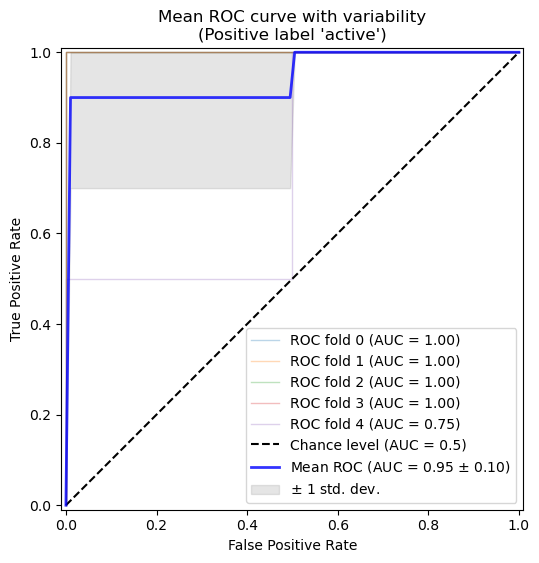

In [63]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(StraGroupKFold.split(x, y, groups=groups)):
    model.fit(x.iloc[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        model,
        x.iloc[test],
        y.iloc[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
        plot_chance_level=(fold == num_folds - 1),
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(Positive label 'active')",
)
ax.legend(loc="lower right")
plt.show()

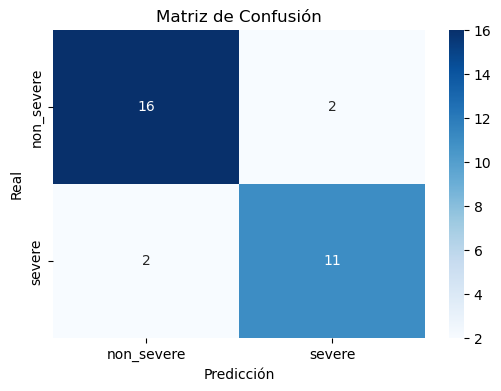

In [64]:
y_prediction = cross_val_predict(model, x, y, cv=StraGroupKFold, groups=groups)

cm_1 = confusion_matrix(y, y_prediction)

plt.figure(figsize=(6,4))
sn.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=['non_severe', 'severe'], yticklabels=['non_severe', 'severe'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# Exercise 2

**Identify and interpret the most important features**

Using the trained Random Forest model from Exercise 1, identify the 25 most important protein features contributing to the classification. Disccus their biological relevance.

In [65]:
feature_importances = model.feature_importances_ # this function tell us how important is every feature (protein) to the model when it takes a decision.
feature_names = x.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

importance_df = importance_df.reset_index(drop=True)

print("Top 25 proteínas más importantes:")
print(importance_df.head(25))

Top 25 proteínas más importantes:
   feature  importance
0   P02768    0.060597
1   P01009    0.056194
2   P12259    0.036335
3   Q06033    0.029234
4   P00751    0.028912
5   P0DJI8    0.028438
6   P35542    0.025746
7   P02741    0.025580
8   P13671    0.025519
9   P15169    0.023919
10  P27918    0.020285
11  P00738    0.019752
12  P19320    0.018593
13  P05156    0.017001
14  Q9UK55    0.016632
15  Q14624    0.015900
16  P01011    0.015734
17  Q14520    0.015482
18  P02750    0.015398
19  Q12907    0.014684
20  P13796    0.013067
21  Q9NQ79    0.012275
22  P01704    0.011626
23  P02766    0.011545
24  P00338    0.011521


/tmp/ipykernel_36226/809064408.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(data = importance_df.head(25),


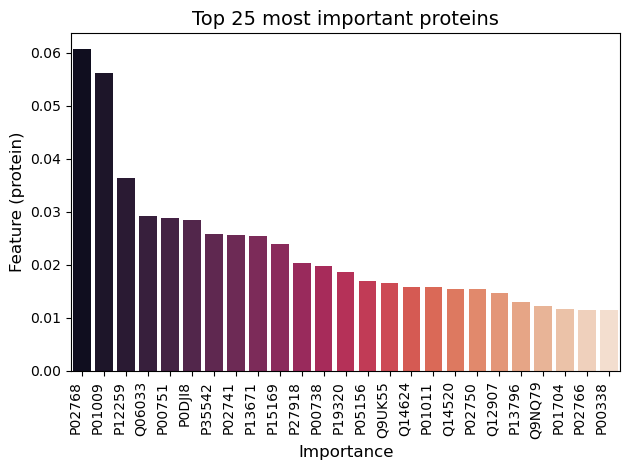

In [66]:
sn.barplot(data = importance_df.head(25), 
           x= 'feature',
           y= 'importance',
           estimator= 'mean',
           errorbar = ('ci', 95),
           orient = None,
           palette='rocket')

plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature (protein)', fontsize=12)
plt.title('Top 25 most important proteins', fontsize=14)
plt.xticks(rotation=90, ha='right') 
plt.tight_layout()
plt.show()


Compare your selected features to the proteins reported by the authors in Supplementary Table 5.

In [67]:
df_table_s5 = pd.read_excel('./raw_data/table_s5.xlsx', sheet_name='Prot_and_meta_matrix', skiprows=1)

In [68]:
df_table_s5 = df_table_s5.iloc[:22, :]
df_table_s5 = df_table_s5.rename(columns={'Unnamed: 0':'Proteins',
                            'Unnamed: 1':'Gene_symbol'})

df_table_s5

,Proteins,Gene_symbol,X2_7,X2_2,X2_3,X2_8,X2_9,X2_26,X2_28,X2_16,...,X2_14,X2_19,X2_11,X2_12,X2_20,X2_21,X2_22,X2_23,X2_24,X2_18
0,P00738,HP,8684102.0,4223429.5,3255135.5,2016219.0,6553195.5,7366545.0,11419414.0,10346288.0,...,8145882.0,5938395.0,3706662.0,7993018.0,7459125.5,2246210.5,9202403.5,6190091.5,7341351.5,55934.0
1,P00751,CFB,201510.0,174418.5,113536.0,72508.5,135942.5,227246.0,151218.0,91948.5,...,212970.0,209905.5,131823.0,203951.5,195782.5,121737.5,206212.0,113293.0,192572.5,105963.5
2,P01011,SERPINA3,1408895.5,716448.0,449664.0,328943.0,724565.5,875477.5,1052248.5,1312499.0,...,1802448.5,1037221.0,424841.0,1109625.0,743447.5,471059.5,1040659.5,590161.0,897242.5,898270.0
3,P02741,CRP,7081.5,1406.0,903.5,1436.0,3293.0,12315.5,4516.5,24675.5,...,5511.5,26389.5,1730.5,32050.5,17020.0,1454.0,51771.5,1966.0,9696.0,2252.5
4,P02748,C9,118250.5,97059.5,54906.0,45464.0,83795.5,120015.5,88899.5,112319.0,...,127288.5,130626.0,74385.0,155768.5,114184.0,58082.0,129408.0,54672.0,106706.0,71070.5
5,P02750,LRG1,77818.5,35720.0,29642.5,24249.5,46048.5,53505.0,25345.5,45950.5,...,44641.5,71591.5,28195.0,51230.0,55066.5,23728.5,64320.5,14257.5,40070.5,44060.0
6,P02768,ALB,1725920.0,1935309.0,2363836.5,1514147.0,3172373.5,1888574.0,1512452.0,2347307.5,...,2079438.5,1859260.0,1858674.5,1754177.0,1564066.0,1647097.0,1565478.5,1823152.5,1699591.5,1152152.5
7,P05155,SERPING1,105072.5,101550.0,66943.0,37384.0,87191.0,78535.0,79831.5,101173.0,...,96250.5,56222.0,52964.5,71886.5,66878.0,60850.5,66644.0,67927.5,84974.5,73656.0
8,P05452,CLEC3B,11107.5,13690.5,16258.0,12306.5,15400.0,12242.5,12358.5,13463.5,...,15708.5,11452.0,13097.5,11957.0,9863.0,14043.0,7833.5,11849.5,12360.0,8473.5
9,P0DJI8,SAA1,545467.0,6656.0,9652.0,2200.0,142152.0,120145.0,46029.0,1341023.0,...,479419.0,499865.0,10657.0,263457.0,86093.0,4231.0,459889.0,9897.0,37118.0,60476.0


In [69]:
protein_paper_list = df_table_s5['Proteins'].tolist()
protein_paper_set = set(protein_paper_list)
protein_paper_set

{'P00738',
 'P00751',
 'P01011',
 'P02741',
 'P02748',
 'P02750',
 'P02768',
 'P05155',
 'P05452',
 'P0DJI8',
 'P0DJI9',
 'P12259',
 'P13671',
 'P13796',
 'P15169',
 'P18428',
 'P51884',
 'Q06033',
 'Q14520',
 'Q86UD1',
 'Q96PD5',
 'Q9UK55'}

In [70]:
protein_model_list = importance_df['feature'].head(25).tolist()
protein_model_set = set(protein_model_list)
protein_model_set

{'P00338',
 'P00738',
 'P00751',
 'P01009',
 'P01011',
 'P01704',
 'P02741',
 'P02750',
 'P02766',
 'P02768',
 'P05156',
 'P0DJI8',
 'P12259',
 'P13671',
 'P13796',
 'P15169',
 'P19320',
 'P27918',
 'P35542',
 'Q06033',
 'Q12907',
 'Q14520',
 'Q14624',
 'Q9NQ79',
 'Q9UK55'}

In [71]:
shared_features = protein_model_set.intersection(protein_paper_set)
print(f"Our model shares {len(shared_features)} protein features with the most relevant proteins identified in the study.")
print(f"Out of the 21 proteins considered, {len(shared_features)} are shared with our model.")
print(f"The shared proteins are as follows: {list(shared_features)}")

Our model shares 14 protein features with the most relevant proteins identified in the study.
Out of the 21 proteins considered, 14 are shared with our model.
The shared proteins are as follows: ['P00738', 'P15169', 'P02750', 'P02741', 'P00751', 'P01011', 'P02768', 'Q06033', 'P12259', 'P13671', 'Q14520', 'P13796', 'P0DJI8', 'Q9UK55']


# Exercise_3

**External prediction on an independent test cohort**

Using the final Random Forest model trained on the full training cohort, predict disease severity for patients in the independent test cohort provided in Supplementary Table 4.

Your task is to:

Apply the trained model to the test cohort.
Obtain predicted probabilities of Severe disease for each patient.
Assign predicted class labels based on these probabilities.
Compare predictions to the true clinical labels.

We upload the test data set (table s4)

In [72]:
df_test_data = pd.read_excel('./raw_data/table_s4.xlsx', sheet_name='Prot_and_meta_matrix', skiprows=1)

In [73]:
df_test_data = df_test_data.iloc[:742, :]

# Rename unnamed columns
df_test_data = df_test_data.rename(columns={
    'Unnamed: 0': 'Proteins', 
    'Unnamed: 1': 'Gene_symbol'
})

# Drop Gene_symbol column to facilitate the cleaning part
df_test_data = df_test_data.drop(columns=['Gene_symbol'])

df_test_data = df_test_data.T

# Use first row as column names
df_test_data.columns = df_test_data.iloc[0]

# Remove the first row (now column names)
df_test_data = df_test_data.iloc[1:]

df_test_data = df_test_data.reset_index().rename(columns={'index': 'patient_id'})

Now, we merge our test dataset with its metadata

In [74]:
df_test_data_merged = pd.merge(df_test_data, df_metadata, on='patient_id', how='inner')
df_test_data_merged
df_group_disease = df_test_data_merged.group_disease
df_test_patients_ids = df_test_data_merged['patient_id']

Problem: The model failed to make predictions because the training set (443 columns) and test set (746 columns) had different features due to inconsistent data preprocessing, specifically, columns with excessive NaN values were removed only from the training set. 

Solution: I identified the 432 common columns between both datasets, filtered both sets to include only these shared features, removed non-predictive metadata columns (patient_id, group_disease, sex, age), and retrained the model with the properly aligned datasets, ensuring all preprocessing steps were applied consistently to both train and test data.

In [75]:
valid_columns_training = df_merged.columns.tolist()
valid_columns_test = df_test_data_merged.columns.tolist()

valid_columns = sorted([col for col in valid_columns_training if col in valid_columns_test])

len(valid_columns), len(valid_columns_test), len(valid_columns_training)

(432, 746, 443)

In [76]:
eliminated_columns = ['patient_id', 'group_disease', 'sex', 'age']
feature_columns = [col for col in valid_columns if col not in eliminated_columns]
x_training = df_merged[feature_columns]
y_training = df_merged['group_disease']

In [77]:
x_test = df_test_data_merged[feature_columns]

y_test = df_group_disease


In [78]:
y_training

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
Name: group_disease, dtype: int64

In [79]:
model_random_forest = RandomForestClassifier(random_state=42)
model_random_forest.fit(x_training, y_training)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [80]:
x_test, y_test

(  A0A075B6H9 A0A075B6I0 A0A075B6I4 A0A075B6I9 A0A075B6J9 A0A075B6K4  \
 0      0.709      1.561      1.419       1.01       1.51      0.884   
 1      1.119      0.854      1.764      0.941      0.977      1.755   
 2      0.696      0.599      0.558      0.763      0.897      0.722   
 3       0.66      0.626      0.657      0.872      0.962      0.948   
 4      0.988      1.082      1.197      1.061      0.902      0.951   
 5      0.633      0.713      0.038      0.831      0.825      0.764   
 6      0.919      1.003      1.276      1.357      0.934      1.268   
 7      0.817      0.849      0.039      0.725      0.787      0.774   
 8      0.721      0.419      0.068      0.521      0.776      0.914   
 9      0.773      0.891       1.14      1.013      0.773       0.77   
 
   A0A075B6K5 A0A075B6K6 A0A075B6Q5 A0A075B6R2  ... Q9UK55 Q9ULI3 Q9UNN8  \
 0      0.888       0.43      0.978      0.904  ...  0.864  0.883  1.013   
 1        1.3      1.102      0.848      1.413  ...  1

In [81]:
probabilities = model_random_forest.predict_proba(x_test)[:,1]
df_prediction = pd.DataFrame({
    'patient_id': df_test_patients_ids,
    'probabilities': probabilities
})

df_prediction

,patient_id,probabilities
0,XG20,0.19
1,XG21,0.47
2,XG22,0.70
3,XG44,0.70
4,XG43,0.81
5,XG23,0.18
6,XG24,0.13
7,XG25,0.67
8,XG46,0.59
9,XG45,0.53


In [82]:
for i, row in df_prediction.iterrows():
    print(f'Predicted probabilities of severe disease for patient {row.patient_id} = {row.probabilities}%')

Predicted probabilities of severe disease for patient XG20 = 0.19%
Predicted probabilities of severe disease for patient XG21 = 0.47%
Predicted probabilities of severe disease for patient XG22 = 0.7%
Predicted probabilities of severe disease for patient XG44 = 0.7%
Predicted probabilities of severe disease for patient XG43 = 0.81%
Predicted probabilities of severe disease for patient XG23 = 0.18%
Predicted probabilities of severe disease for patient XG24 = 0.13%
Predicted probabilities of severe disease for patient XG25 = 0.67%
Predicted probabilities of severe disease for patient XG46 = 0.59%
Predicted probabilities of severe disease for patient XG45 = 0.53%


I chose the default 0.5 to reduce false positives and improve precision. This means the model will only classify a case as 'severe'  when it's more confident (≥50% probability), minimizing unnecessary severe classifications.

In [83]:
y_prediction_test = np.where(probabilities >= 0.50, 'severe', 'non_severe')
df_prediction['class_labels'] = y_prediction_test
df_prediction

,patient_id,probabilities,class_labels
0,XG20,0.19,non_severe
1,XG21,0.47,non_severe
2,XG22,0.70,severe
3,XG44,0.70,severe
4,XG43,0.81,severe
5,XG23,0.18,non_severe
6,XG24,0.13,non_severe
7,XG25,0.67,severe
8,XG46,0.59,severe
9,XG45,0.53,severe


Text(0.5, 1.0, 'Matriz de Confusión')

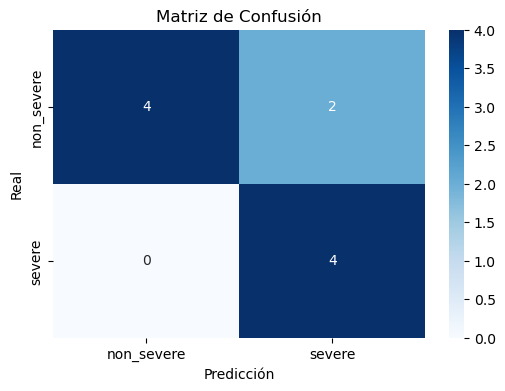

In [84]:
cm_1 = confusion_matrix(y_test, y_prediction_test)

plt.figure(figsize=(6,4))
sn.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=['non_severe', 'severe'], yticklabels=['non_severe', 'severe'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')

In [85]:
print(classification_report(y_test, y_prediction_test))

              precision    recall  f1-score   support

  non_severe       1.00      0.67      0.80         6
      severe       0.67      1.00      0.80         4

    accuracy                           0.80        10
   macro avg       0.83      0.83      0.80        10
weighted avg       0.87      0.80      0.80        10



**How does the model perform on the independent test cohort?**

The model demonstrates strong predictive performance with 80% overall accuracy across 10 cases. For non-severe cases (n=6), the model achieves perfect precision (100%) and 67% recall, meaning that when it predicts non-severe outcomes it is always correct, though it misclassifies one-third of actual non-severe cases as severe. For severe cases (n=4), the model shows 67% precision with perfect recall (100%), successfully identifying all severe cases but generating some false alarms by misclassifying non-severe cases as severe. Both classes achieve identical F1-scores of 0.80, indicating balanced performance across severity levels. The model exhibits a bias toward predicting severe outcomes, which may be clinically appropriate as it ensures no severe cases are missed while accepting some false positives. However, the small sample size significantly limits the reliability of these metrics and the model's ability to generalize to larger populations.